## Lab3-Assignment (Hawra Almadeh)

In [ ]:
#DataSet From Kaggle Link: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("dirty_cafe_sales.csv")

# Display first 5 rows
df.head(7)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06


In [ ]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

The dataset has 9741 rows and 8 columns

In [7]:
# viewing the data types of columns
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

As illustrated above the data type inspection shows that several columns are stored as object types, including date and monetary values. While categorical features are expected to be objects, date and numerical values stored as objects indicate formatting issues. In order to correct theses issues we need to futhure invistogate what is causeing them.

In [8]:
print(df.isna().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


As we can see there is a large number of rows with missing values. Having missing values can effect later statistical analysiss and data visualization. Next we are going to attempt to clean as much as we can of the dirty data.

In [10]:
df = df.dropna(subset=['Item'])
print(df.isna().sum())

Transaction ID         0
Item                   0
Quantity             135
Price Per Unit       172
Total Spent          169
Payment Method      2497
Location            3161
Transaction Date     153
dtype: int64


Since we can not fix missing items name or replace them by calulations. The best approach is to delete the rows with missing item names. After running the data type analysis again we can see that we have zero missing item rows.

In [ ]:
df['Item'].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',    'ERROR',    'Juice',      'Tea']
Length: 10, dtype: str

While droping the rows with missing items have fixed the missing values problem we could still have rows that contain values other than the acutll items names. To find these rows, we can make a list of valid na,es and compare each row to see if the item name is there.

In [39]:
valid_items = ['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich', 'Juice', 'Tea'] 

# 2. Check for rows where the item name is NOT in the correct list
# (This automatically catches 'UNKNOWN', 'ERROR', 'error', and blank NaN cells)
invalid_items = ~df['Item'].isin(valid_items)

print(f"Total rows with invalid items names: {invalid_items.sum()}")

Total rows with invalid items names: 636


We can see how there are 636 rows that containg invalid names like UNKOWN and ERROR from the list of items names we printined above using the unique funstion on the item row. with that we make a list  of valid names then count these rows with sum function. What is left is to drop these rows so we have a clean item column with correct data.

In [40]:
dirty_rows = df[~df['Item'].isin(valid_items)].index

df.drop(dirty_rows, inplace=True)
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich', 'Juice', 'Tea']
Length: 8, dtype: str

Using index to find the indecies of the rows with invalid items names, we can then drop them using the drop function. After that we print a list of unique item names to do a final check that these rows are gone.

In [ ]:
non_numeric_quantity = df[pd.to_numeric(df['Quantity'], errors='coerce').isna()]
non_numeric_unitprice = df[pd.to_numeric(df['Price Per Unit'], errors='coerce').isna()]
non_numeric_total_spent = df[pd.to_numeric(df['Total Spent'], errors='coerce').isna()]

print(non_numeric_quantity['Quantity'].unique())
print(non_numeric_unitprice['Price Per Unit'].unique())
print(non_numeric_total_spent['Total Spent'].unique())

<StringArray>
['ERROR', 'UNKNOWN', nan]
Length: 3, dtype: str
<StringArray>
[nan, 'ERROR', 'UNKNOWN']
Length: 3, dtype: str
<StringArray>
['ERROR', nan, 'UNKNOWN']
Length: 3, dtype: str


Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

By trying to convert string columns to numerical data, we can see wha cuasing these columns to fail caonverting. As shown above we have thse sting values ['ERROR', nan, 'UNKNOWN'] in some of the columns that causing the data type issue. To aatempt and fix this we can try replacing the missing values with the correct numerical data.

In [20]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df.dtypes

Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
dtype: object

The first step is to unifiy the non numerical values. This so it makes it easier to replace the values later. Using to_numeric function to convert to force convert the string columns into numerical data will auto replace all non numerical values with "NaN" in which we can then replace with correct values. As we can see after converting the columns to numerical.Running dtypes again the columns data type has changed to numbers.

In [21]:
# Fill missing Quantities (Total Spent / Price Per Unit)
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

#Fill missing Unit Prices (Total Spent / Quantity)
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])

# Fill missing Totals (Quantity * Price Per Unit)
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

In here, after converting all non numerical values to nan we can now starting cleaning the data by replacing each value with a corospoding numbercal value. We can get the missing Quantitiy values by dividing the total spent amount iver the unit price. and get the unit price by dividing the total spent over the quantity, lastly get the total price by multiplying the quantity values with the unit price.

In [22]:
print(df.isna().sum())

Transaction ID         0
Item                   0
Quantity              37
Price Per Unit        36
Total Spent           39
Payment Method      2497
Location            3161
Transaction Date     153
dtype: int64


Now, we can see how this appraoch has significanly fixed most of the isuues. But, we still have some rows with na values. That becuase these row are missing more than one values for the three columns we used to replace the missing values. So when the caluculations happed the arguments will likely be Nan to NaN which in turn will also produce a NaN eventually.

In [ ]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df.groupby('Item')['Price Per Unit'].transform('median'))

df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

Let's take a different path to fix the remaining rows. since the product would usually have the same price, we can find the unit price by averaging known unit prices in other columns for which the product and unit price is known. this allows us to replace the quantity and total spent by finding the unit price then applying the same calulations as earlier.

In [24]:
print(df.isna().sum())

Transaction ID         0
Item                   0
Quantity              20
Price Per Unit         0
Total Spent           20
Payment Method      2497
Location            3161
Transaction Date     153
dtype: int64


Final rundown for the numerical columns. As shown running the command to find the missing data rows we can see how we eliminated the missing values from the unit price column and few others from the quantity and total spent column. We can now coclud that any further cleaning for these columns is not feasable so our on;y option is to drop the remaining 20 rows.

In [26]:
df = df.dropna(subset=['Quantity'])
print(df.isna().sum())

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2490
Location            3156
Transaction Date     153
dtype: int64


No let's move on, and tackle another problem with this data. Take a look at the Payment Method and Location. There is a large number of missing values in these columns. Since we can not fix this with calulations. Or estimate a location or a payment method using other known columns. The safest way to fix this is to create a values that can corropond to missing values so that this missing data does not effect future analysis.

In [27]:
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')
print(df.isna().sum())

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    153
dtype: int64


Now what if the rows contain values that are not missing, but they just do not belong there like having "ERROR" in th location or Payment Method. which is a values just not correct. To find such rows we can 

In [ ]:
# Change 'Quantity' to whichever numerical column you are testing
anomalies = df[pd.to_numeric(df['Payment Method'], errors='coerce').isna() & df['Payment Method'].notna()]
print(anomalies['Payment Method'].unique())
# Change 'Quantity' to whichever numerical column you are testing
anomalies = df[pd.to_numeric(df['Location'], errors='coerce').isna() & df['Location'].notna()]
print(anomalies['Location'].unique())


<StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', 'Unknown']
Length: 6, dtype: str
<StringArray>
['Takeaway', 'In-store', 'UNKNOWN', 'Unknown', 'ERROR']
Length: 5, dtype: str


To clean these rows, we can replace the other incorrect values just like the missing ones with UNKNOWN.

In [32]:
correct_payments = ['Credit Card', 'Cash', 'Digital Wallet']
correct_locations = ['Takeaway', 'In-store']

df.loc[~df['Payment Method'].isin(correct_payments), 'Payment Method'] = 'UNKNOWN'
df.loc[~df['Location'].isin(correct_locations), 'Location'] = 'UNKNOWN'

print(df['Payment Method'].unique())
print(df['Location'].unique())

<StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet']
Length: 4, dtype: str
<StringArray>
['Takeaway', 'In-store', 'UNKNOWN']
Length: 3, dtype: str


We can see how the other values are now gone, and has been replaced with UNKNOWN as a value for missing data. For the last missing values column we need to look at date. Now logically transaction errors happens if now transactions were to be executed at the same time. This means We can actullay take the time of a known transaction date and plug it in the missing transaction field.

In [33]:
df['Transaction Date'] = df['Transaction Date'].ffill()
print(df.isna().sum())

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


Luckly, Pandas offer a direct way to do this using ffill function which takes the values of the top row and fills the row right under with it. After applying this method and re running the missing values command. we now have zero missing values in any of the columns.

In [41]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (9011, 8) 

number of rows:  9011
number of columns:  8


Our clean dataset has 9011 rows now from the original 9741 after cleaning.

In [46]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

There are no duplicate rows.

Statistical Summery of categorical and text columns 

In [45]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,9011,9011,9011.000000,9011.000000,9011.000000,9011,9011,9011
unique,9011,8,NaN,NaN,NaN,4,3,367
top,TXN_1961373,Juice,NaN,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN
freq,1,1168,NaN,NaN,NaN,2870,3577,146
mean,NaN,NaN,3.027633,2.949062,8.943347,NaN,NaN,NaN
std,NaN,NaN,1.423761,1.279464,6.016236,NaN,NaN,NaN
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,NaN
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,NaN


### Univariate Analysis

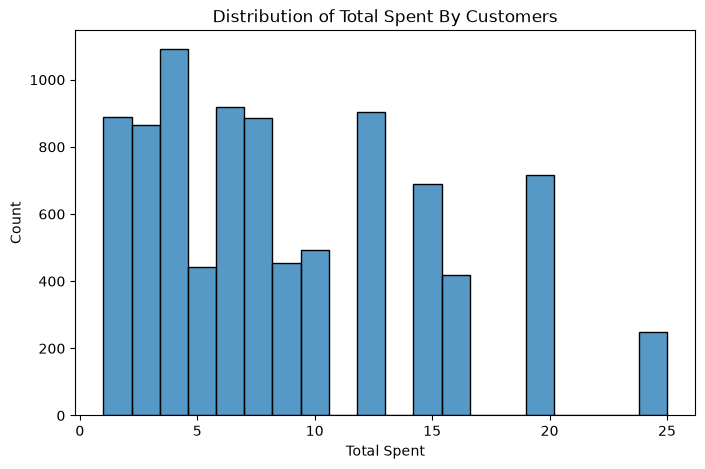

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Spent'], bins=20)
plt.title("Distribution of Total Spent By Customers")
plt.show()

The total spent of customers is somewhat right skewed, many customers total spent is around 10 or less.

### Bivariate Analysis

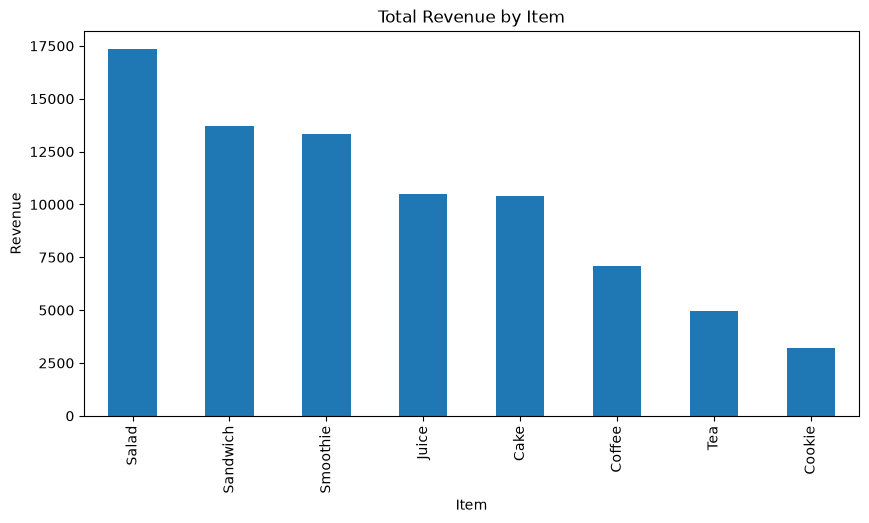

Item
Salad       17345.0
Sandwich    13716.0
Smoothie    13344.0
Juice       10515.0
Cake        10404.0
Coffee       7072.0
Tea          4960.5
Cookie       3232.0
Name: Total Spent, dtype: float64

In [59]:
item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
item_revenue.plot(kind='bar')
plt.title("Total Revenue by Item")
plt.ylabel("Revenue")
plt.show()

item_revenue

From the plot we can see that Salad is the best seller in the cafe, returing over 15000 in in sales, while cookies are sales are very low with a total revenue of 3232.

### Total Spent VS Unit Price

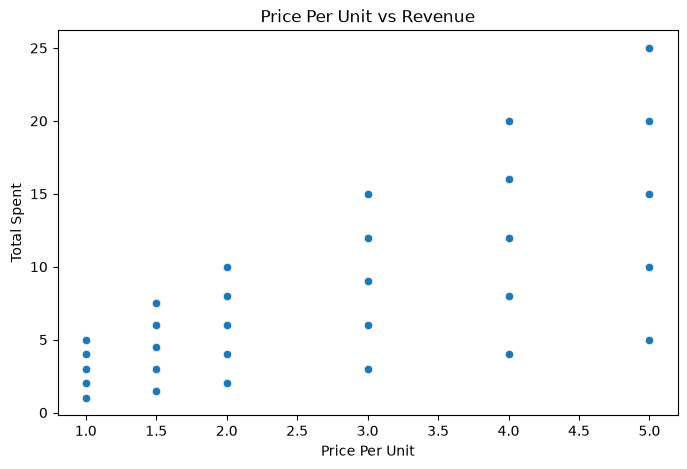

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price Per Unit', y='Total Spent', data=df)
plt.title("Price Per Unit vs Revenue")
plt.show()

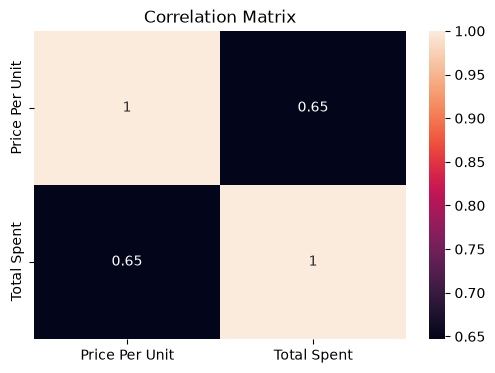

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Price Per Unit', 'Total Spent']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Since unit prices are fixed a the point in the scatter plot are stacked and can not by seen. from this heat map we can see how the relation between the price of the item and the totl spent by customers have a moderate correlation which suggest there might be a connection between the two where cutomers may spend more on items with higher prices.

### Location Revenue Trend

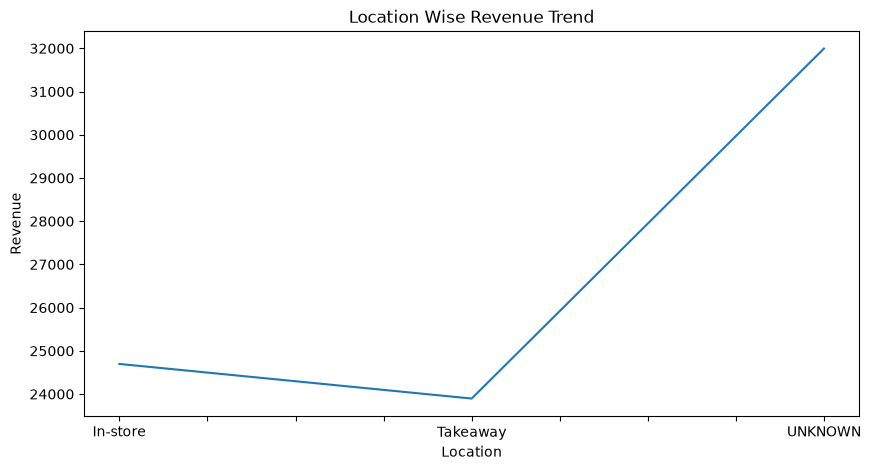

In [66]:


loc_revenue = df.groupby('Location')['Total Spent'].sum()

plt.figure(figsize=(10,5))
loc_revenue.plot()
plt.title("Location Wise Revenue Trend")
plt.ylabel("Revenue")
plt.show()

The plot shows how customers might be spending more when ordering takeways compared to shopping in-store